# Mutating molecules
Applying small graph transforms such as atoms deletions,
transforms, insertions etc is an interesting way to explore the direct near neighbors of a molecule (from the graph edit distance point of view). However, it's know these type of mutations frequently lead to chemically nonsensical structure (e.g. see [NONPHER](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-017-0206-2) )

## Mutating sulpiride

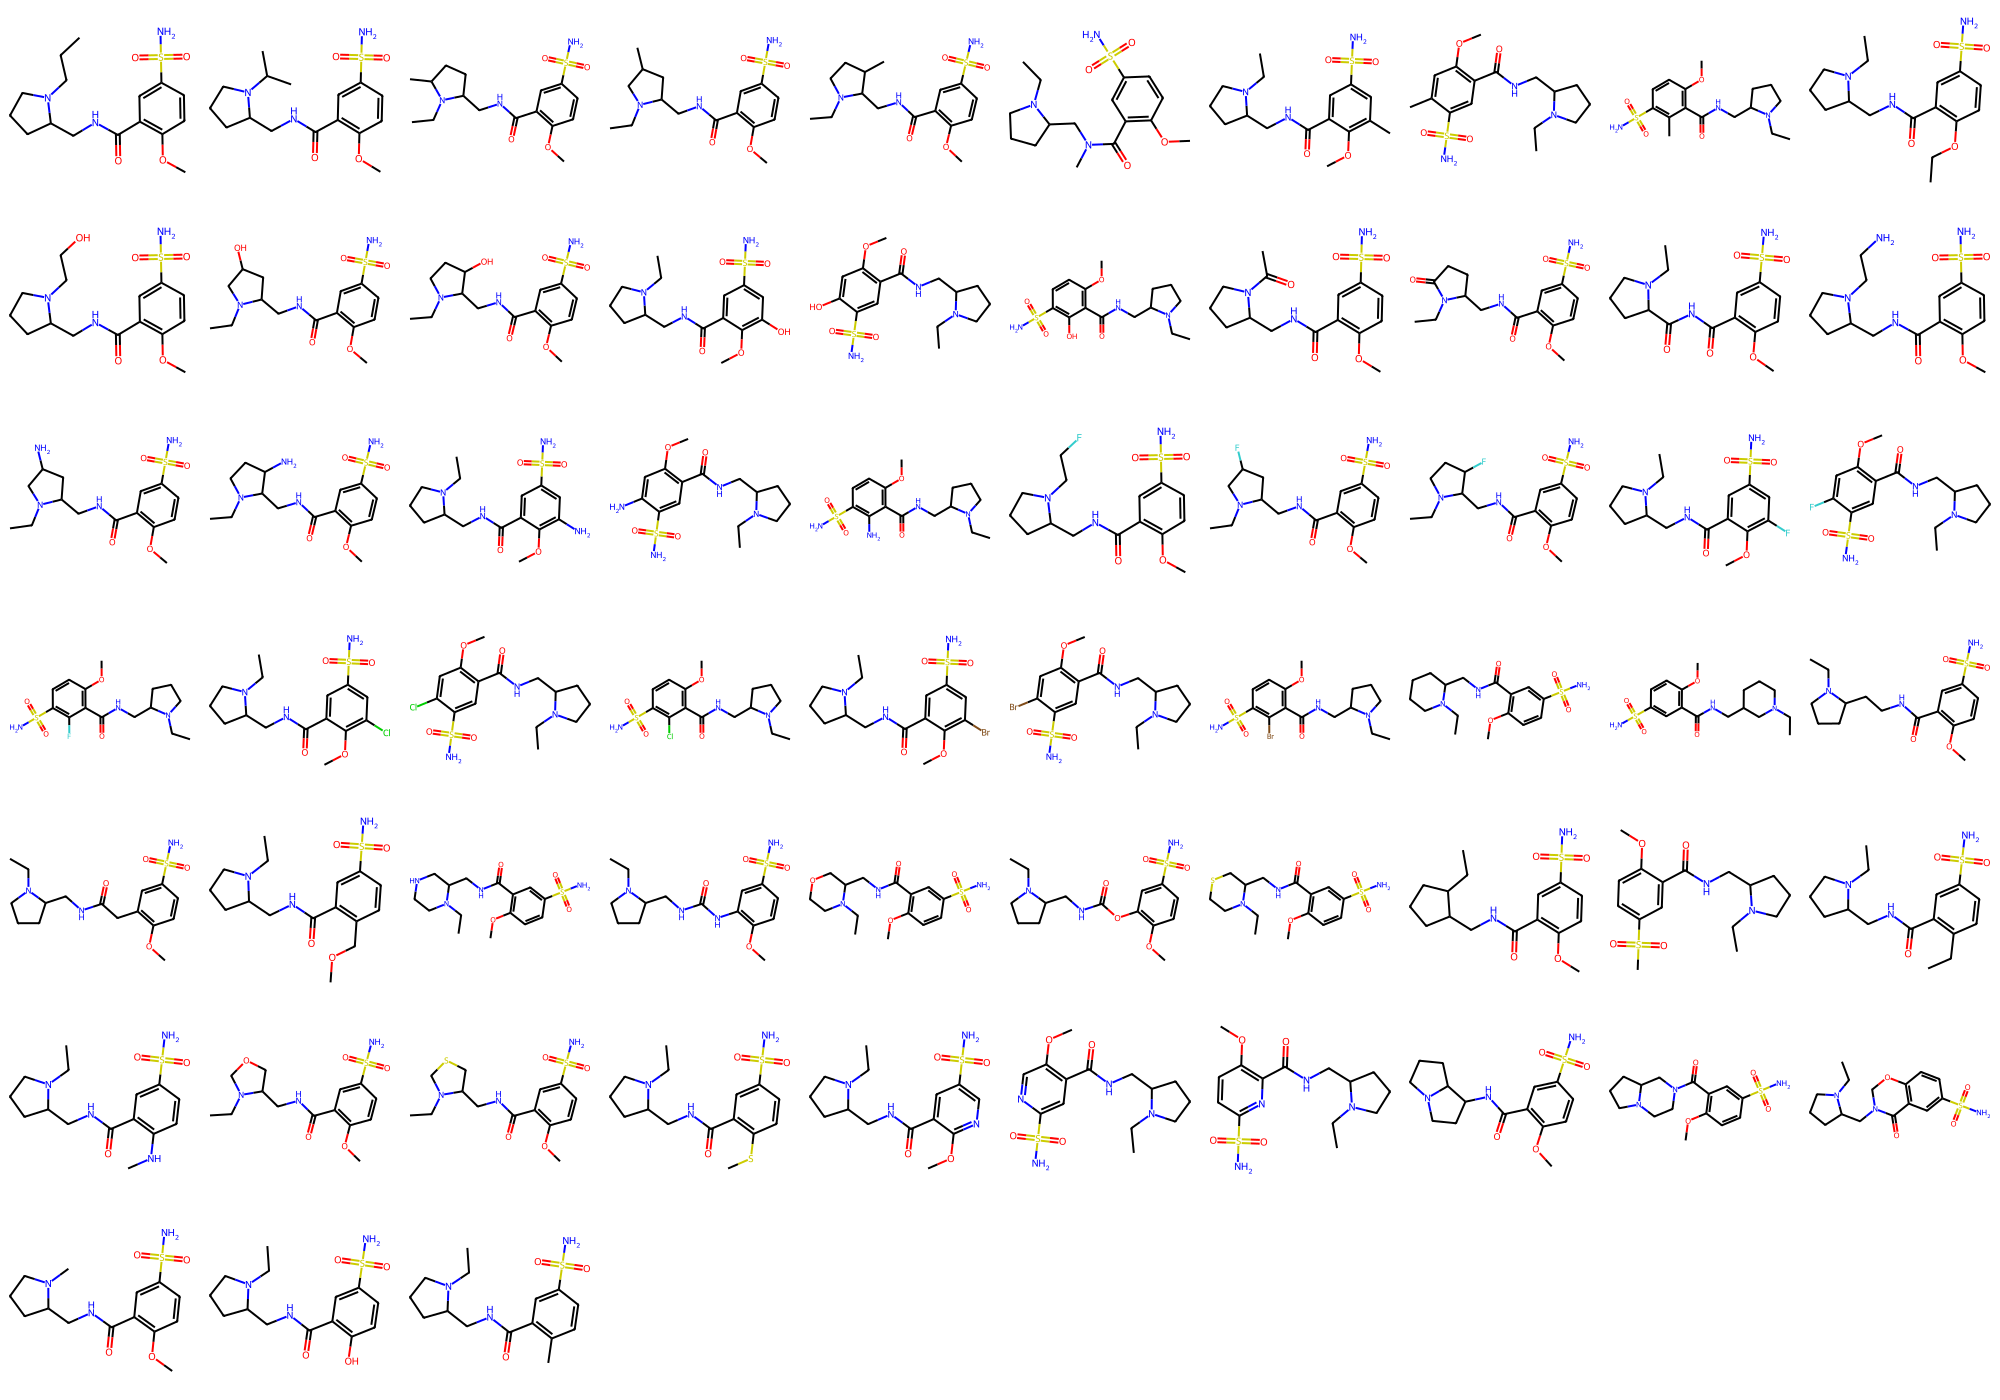

In [1]:
from rdkit import Chem
from lacan import lacan
from lacan import mutate
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.drawMolsSameScale=False
# load sulpiride
m = Chem.MolFromSmiles("CCN1CCCC1CNC(=O)C2=C(C=CC(=C2)S(=O)(=O)N)OC ")
# load lacan profile
p = lacan.load_profile("chembl")
# mutate the molecule once
mutated_molecules = mutate.apply_mutations(m,p,0.8)
# show the results
d = Draw.MolsToGridImage(mutated_molecules,molsPerRow=10,maxMols=500)
display(d)

## applying several mutations
The mutated molecules can be mutated once again.

/home/wim/anaconda3/envs/lactest/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


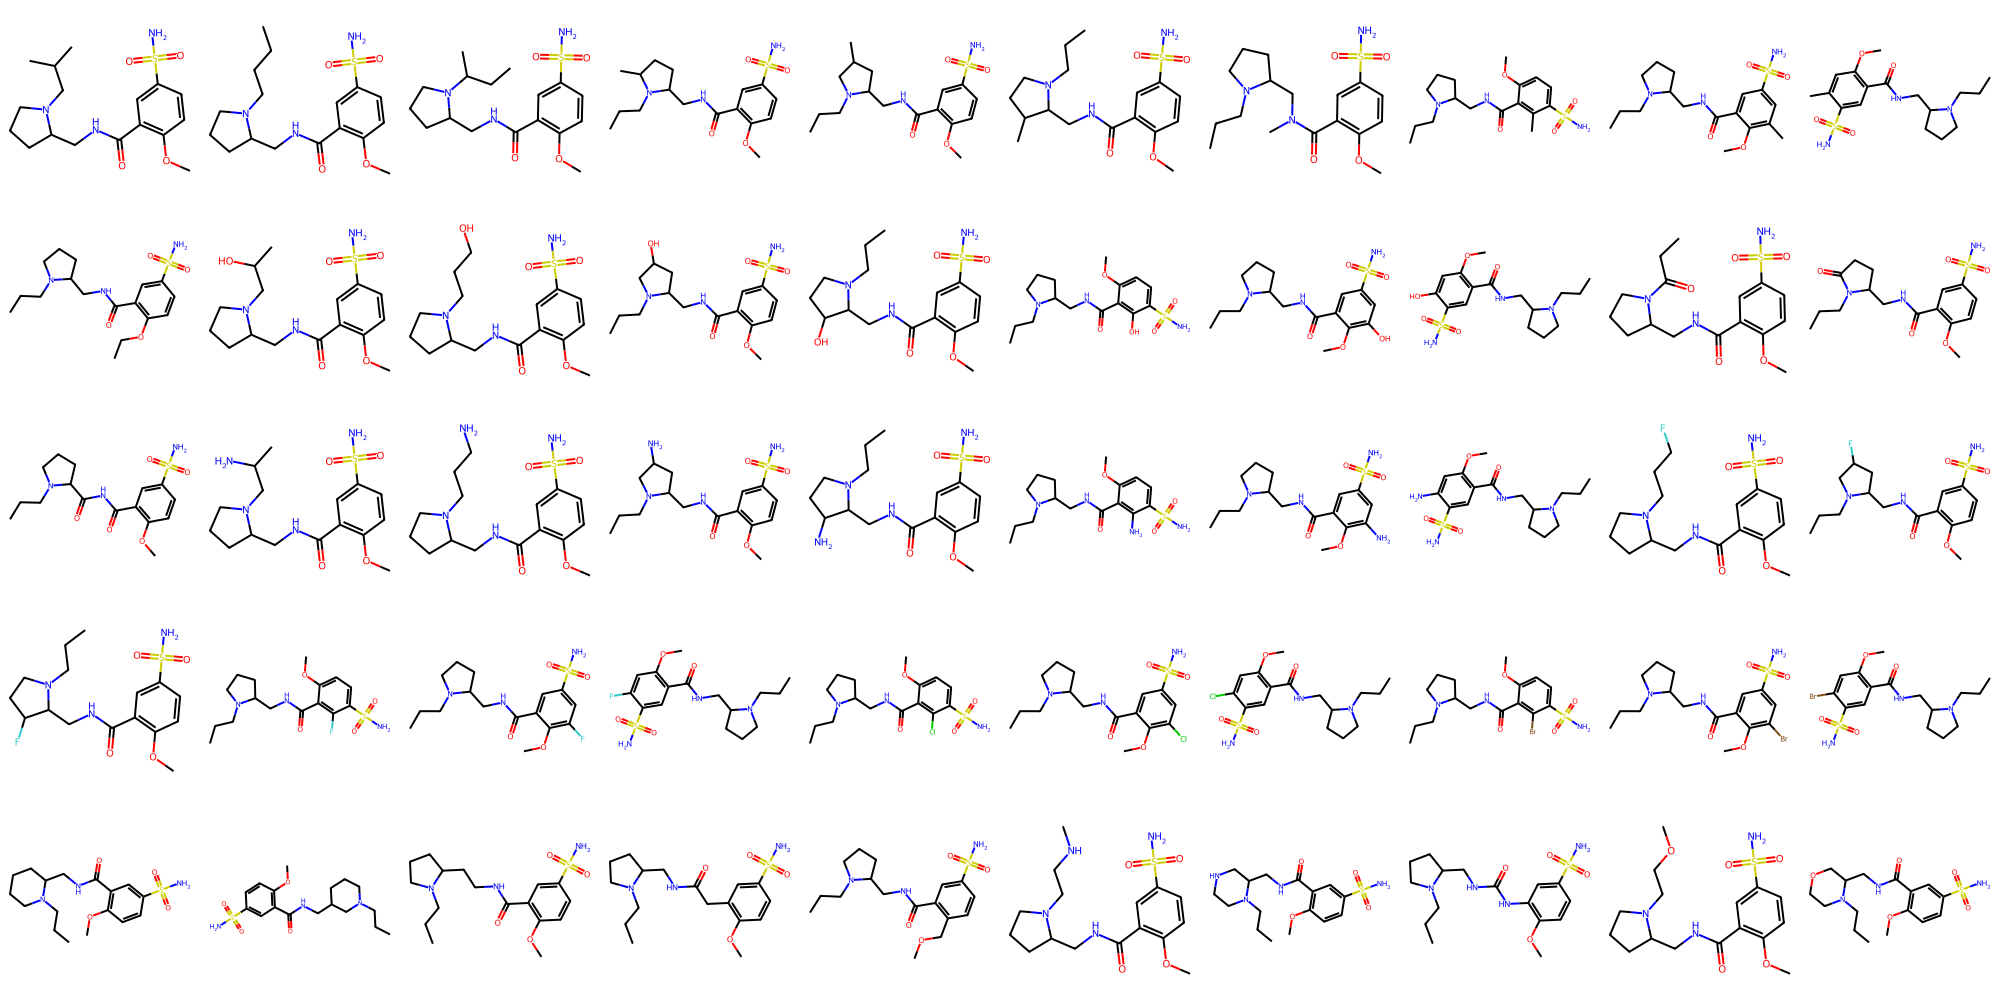

In [2]:
#mutate all the molecules from the previous block
mutated_molecules2 = [mutate.apply_mutations(m,p,0.8) for m in mutated_molecules]
mutated_molecules2 = [item for sublist in mutated_molecules2 for item in sublist] #flatten
# show the results
d = Draw.MolsToGridImage(mutated_molecules2,molsPerRow=10,maxMols=50)
display(d)

This gives a pretty large list of molecule. So, let's retain only molecules with 4 or more SSSR rings. Interestingly, most cyclization were rejected by LACAN and only two derivatives remain.

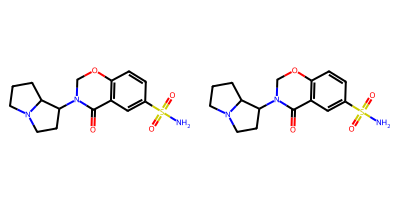

In [3]:
rings_4 = [m for m in mutated_molecules2 if len(Chem.GetSSSR(m))>=4]
# show the results
d = Draw.MolsToGridImage(rings_4,molsPerRow=2)
display(d)